In [1]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
ENV["JULIA_REVISE_POLL"]="1";
using Revise

In [2]:
using PyPlot, PyCall, Peaks, Statistics, JJDFTX, DelimitedFiles, LinearAlgebra;
using JJDFTX: kinetic_energy

Your version of python is not linked to helper_scripts.py
Congratulations- Your version of python is linked to the Atomic Simulation Environment


In [3]:
HwannierUp, cell_mapUp = hwannier("wannierUp"), np.loadtxt("wannierUp.map.txt");
HwannierDn, cell_mapDn = hwannier("wannierDn"), np.loadtxt("wannierDn.map.txt");
lattice_vectors = loadlattice("wannier.out");

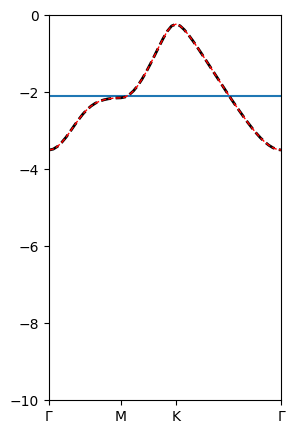

(0.0, 55.0)

In [4]:
figure(figsize=(3, 5))
plot_bands(HwannierDn, cell_mapDn, color="black", linewidth=2, linestyle="dashed", whichbands=[13])
plot_bands(HwannierDn, cell_mapDn, color="red", linewidth=1, linestyle="dashed", whichbands=[13])
ylim(-10, 0)
hlines([-2.088258123632972], 0, 55)
label_plots()

In [20]:
# Find Chemical Potential
Energies, DOS = density_of_states(HwannierUp, cell_mapUp, Val(2), histogram_width=100, mesh=20, monte_carlo=true, num_blocks=100)

([-26.83822520878977, -26.828225222088694, -26.818225235387622, -26.808225248686547, -26.798225261985475, -26.7882252752844, -26.77822528858333, -26.768225301882254, -26.758225315181182, -26.748225328480107  …  6.161730904752627, 6.171730891453702, 6.181730878154777, 6.191730864855845, 6.2017308515569205, 6.211730838257996, 6.221730824959071, 6.231730811660139, 6.241730798361214, 6.251730785062289], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

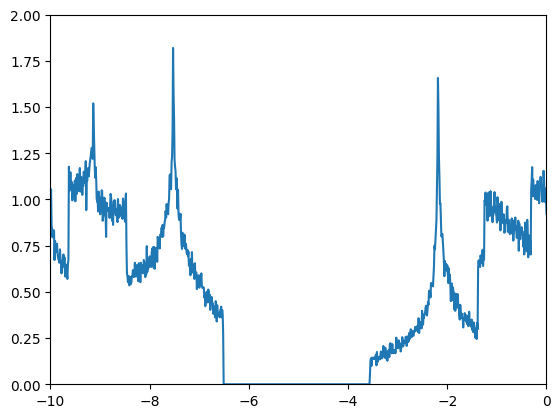

(0.0, 2.0)

In [22]:
plot(Energies, DOS)
xlim(-10, 0)
ylim(0, 2)

In [24]:
x, y = find_chemical_potential(Energies, DOS)

([-26.828225222088694, -26.818225235387622, -26.808225248686547, -26.798225261985475, -26.7882252752844, -26.77822528858333, -26.768225301882254, -26.758225315181182, -26.748225328480107, -26.738225341779035  …  6.161730904752627, 6.171730891453702, 6.181730878154777, 6.191730864855845, 6.2017308515569205, 6.211730838257996, 6.221730824959071, 6.231730811660139, 6.241730798361214, 6.251730785062289], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  20.99997207225426, 20.99997207225426, 20.99997207225426, 20.999972072254256, 20.999972072254256, 20.99997207225426, 20.999972072254256, 20.99997207225426, 20.99997207225426, 20.99997207225426])

In [25]:
println(x[argmin(abs.(y .- 12.5))])

-2.088258123632972


In [9]:
kpoints = bandstructkpoints2q(interpolate=5);
energies = collect(range(0, 100, length=10000));

In [32]:
epsilons_default = zeros(50, 200);
for (i, k) in enumerate(kpoints[1:50])
    i == 1 && continue
    polarizations = parse.(Float64, readlines("Plasmon.out-$i"))
    for (j, ω) in enumerate(range(0.05, 1.5, length=200))
        epsilons_default[i, j] = abs(ϵ(k, lattice_vectors, ω, energies, smooth(polarizations, win_len=10), Val(2), Val(:default), limit=20, δ=0.001, normalized=true))
    end
end

In [52]:
epsilons_scipy = zeros(50, 200)
for (i, k) in enumerate(kpoints[1:50])
    println(i); flush(stdout)
    i == 1 && continue
    polarizations = parse.(Float64, readlines("Plasmon.out-$i"))

    for (j, ω) in enumerate(range(0.05, 1.5, length=200))
       epsilons_scipy[i, j] = real(ϵ(k, lattice_vectors, ω, energies, smooth(real.(polarizations), win_len=10), Val(2), Val(:scipy), limit=200, δ=0.001, normalized=true))
    end
end

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50


In [33]:
plasmon_default = [range(0.05, 1.5, length=200)[argmin(x)] for x in eachrow(log.(abs.(epsilons_default[2:15, :])))];
plasmon_default = [0, plasmon_default...]
qs_default, confinements = confinement(lattice_vectors, kpoints[1:15], plasmon_default)
confinements[1] = 0
plasmon_default = smooth(plasmon_default, win_len=1)
confinements = smooth(confinements, win_len=1);
plasmon_default[1] = 0
confinements[1] = 0;

In [25]:
plasmon_scipy = [range(0.05, 1.5, length=200)[argmin(x)] for x in eachrow(log.(abs.(smooth(epsilons_scipy[2:25, :], win_len=100))))];
plasmon_scipy = [0, plasmon_scipy...]
qs, confinements = confinement(lattice_vectors, kpoints[1:25], plasmon_scipy)
confinements[1] = 0
plasmon_scipy = smooth(plasmon_scipy, win_len=1)
confinements = smooth(confinements, win_len=1);
plasmon_scipy[1] = 0
confinements[1] = 0;

LoadError: UndefVarError: epsilons_scipy not defined

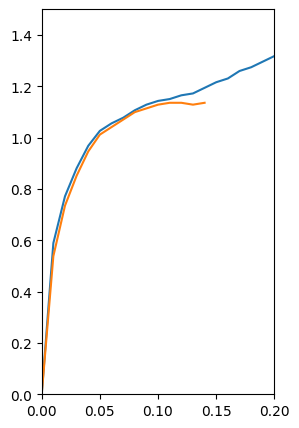

(0.0, 1.5)

In [34]:
figure(figsize=(3, 5))
plot(qs, plasmon_scipy)
plot(qs_default, plasmon_default)

xlim(0, 0.2)
ylim(0, 1.5)

In [129]:
np.savetxt("Plasmon.txt", hcat(qs, plasmon_scipy, confinements))

In [24]:
qs, plasmon_scipy, confinements = [collect(x) for x in eachcol(np.loadtxt("Plasmon.txt"))];

In [12]:
landau_lower_alt = zeros(25);
landau_upper_alt = zeros(25);
for (i, k) in enumerate(kpoints[1:25])
    polarizations = parse.(Float64, readlines("Plasmon.out-$i"))
    non_zero_impols = energies[findall(.!iszero.(polarizations))]
    landau_lower_alt[i] = maximum([filter(x-> x < plasmon_scipy[i], non_zero_impols)..., 0])
    landau_upper_alt[i] = minimum(filter(x-> x > plasmon_scipy[i], non_zero_impols))
end

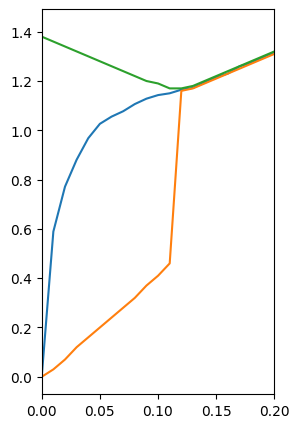

(0.0, 0.2)

In [37]:
figure(figsize=(3, 5))
plot(qs, plasmon_scipy)
plot(qs, landau_lower_alt)
plot(qs, landau_upper_alt)

xlim(0, 0.2)

In [38]:
np.savetxt("Landau.txt", hcat(qs, landau_lower_alt, landau_upper_alt))